# Artemis I Trans Lunar Injection (TLI) Orbital Sim

simulates the Artemis I TLI burn (November 16, 2022) validates against JPL Horizons "ground truth" state vectors, and quantifies error contributions from each perturbation source

## Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from datetime import datetime, timedelta
import spiceypy as spice
from astroquery.jplhorizons import Horizons
from astropy.time import Time
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True

### Physical Constants and Mission Parameters

In [2]:
# === Physical Constants ===
MU_EARTH = 398600.4418       # Earth gravitational parameter [km^3/s^2]
MU_MOON = 4902.8001          # Moon gravitational parameter [km^3/s^2]
MU_SUN = 1.32712440018e11    # Sun gravitational parameter [km^3/s^2]
R_EARTH = 6378.137           # Earth equatorial radius [km]
J2_EARTH = 1.08263e-3        # Earth J2 coefficient
G0 = 9.80665e-3              # Standard gravity [km/s^2] 
AU_KM = 1.495978707e8        # 1 AU in km
C_LIGHT = 299792.458         # Speed of light [km/s]
SOLAR_FLUX = 1367.0          # Solar flux at 1 AU [W/m^2]

In [3]:
# === ICPS RL10-B-2 Engine Parameters ===
THRUST_NOMINAL = 110.0       # Nominal thrust [kN] = 110,000 N
ISP = 465.5                  # Specific impulse [s]
THRUST_RAMP_TIME = 5.0       # Time to reach full thrust [s]

# === Artemis I TLI Burn Parameters ===
TLI_START_UTC = '2022-11-16T08:17:11'  # TLI ignition
TLI_END_UTC = '2022-11-16T08:35:11'    # Engine cutoff (ECO)
BURN_DURATION = 18 * 60.0              # ~18 minutes [s]

# === Orion Spacecraft Parameters (approximate) ===
ORION_MASS_INITIAL = 26500.0  # Initial mass estimate [kg] (Orion + service module + ICPS residual)
ORION_AREA = 25.0             # Cross-sectional area estimate [m^2]
CR_SRP = 1.5                  # SRP reflectivity coefficient

# Compute mass flow rate: mdot = T / (Isp * g0)
MDOT_NOMINAL = (THRUST_NOMINAL * 1000) / (ISP * 9.80665)  # [kg/s] using SI g0
print(f"Nominal mass flow rate: {MDOT_NOMINAL:.2f} kg/s")
print(f"Expected propellant consumption: {MDOT_NOMINAL * BURN_DURATION:.1f} kg over {BURN_DURATION/60:.1f} min")

Nominal mass flow rate: 24.10 kg/s
Expected propellant consumption: 26024.1 kg over 18.0 min


### Load SPICE 

high precision ephemeris data for planets 
- `naif0012.tls` - Leap seconds kernel (UTC - ET conversion)
- `de440s.bsp` - Planetary ephemeris (positions of Earth, Moon, Sun)
- `pck00011.tpc` - Planetary constants (radii, rotation)

In [4]:
def load_spice_kernels():
    """Load SPICE kernels for ephemeris calculations."""
    kernel_path = "../../data/eclipse/"
    spice.furnsh(kernel_path + "naif0012.tls")  # Leap seconds
    spice.furnsh(kernel_path + "de440s.bsp")    # Planetary ephemeris
    spice.furnsh(kernel_path + "pck00011.tpc")  # Planetary constants
    print("SPICE kernels loaded successfully")

load_spice_kernels()

SPICE kernels loaded successfully


### Time Conversion Utilities

**Critical:** JPL Horizons uses UTC timestamps, but SPICE operates in Ephemeris Time (ET/TDB). The difference is ~69 seconds due to accumulated leap seconds. All SPICE calls must use ET.

In [5]:
def utc_to_et(utc_string):
    return spice.str2et(utc_string) #+ ' UTC'

def et_to_utc(et):
    return spice.et2utc(et, 'ISOC', 0)

# Verify 
et_start = utc_to_et(TLI_START_UTC)
et_end = utc_to_et(TLI_END_UTC)
print(f"TLI Start: {TLI_START_UTC} UTC -> ET = {et_start:.3f} s past J2000")
print(f"TLI End:   {TLI_END_UTC} UTC -> ET = {et_end:.3f} s past J2000")
print(f"Burn duration: {et_end - et_start:.1f} seconds")

TLI Start: 2022-11-16T08:17:11 UTC -> ET = 721858700.183 s past J2000
TLI End:   2022-11-16T08:35:11 UTC -> ET = 721859780.183 s past J2000
Burn duration: 1080.0 seconds


## Ground Truth Data

Query JPL Horizons for Artemis I (NAIF ID: -1023) state vectors during the TLI burn window 

In [6]:
def fetch_horizons_vectors(target_id, center, start_time, stop_time, step='1m'):
    """Fetch state vectors from JPL Horizons.
    
    Args:
        target_id: NAIF ID or name (e.g., '-1023' for Artemis I)
        center: Reference body (e.g., '@399' for Earth-centered)
        start_time: Start UTC time string
        stop_time: Stop UTC time string
        step: Time step (e.g., '1m' for 1 minute)
    
    Returns:
        Dictionary with 'times_utc', 'times_et', 'positions', 'velocities'
    """
    obj = Horizons(id=target_id, location=center,
                   epochs={'start': start_time.replace('T', ' '),
                           'stop': stop_time.replace('T', ' '),
                           'step': step})
    
    vectors = obj.vectors(refplane='earth')
    
    # Extract position and velocity (Horizons returns in AU and AU/day by default)
    # Convert to km and km/s
    AU_TO_KM = 1.495978707e8
    DAY_TO_SEC = 86400.0
    
    # times_utc = [str(t).replace(' ', 'T') for t in vectors['datetime_str']]
    times_utc = [str(t) for t in vectors['datetime_str']]
    times_et = np.array([utc_to_et(t) for t in times_utc])
    
    positions = np.column_stack([
        vectors['x'].value * AU_TO_KM,
        vectors['y'].value * AU_TO_KM,
        vectors['z'].value * AU_TO_KM
    ])
    
    velocities = np.column_stack([
        vectors['vx'].value * AU_TO_KM / DAY_TO_SEC,
        vectors['vy'].value * AU_TO_KM / DAY_TO_SEC,
        vectors['vz'].value * AU_TO_KM / DAY_TO_SEC
    ])
    
    return {
        'times_utc': times_utc,
        'times_et': times_et,
        'positions': positions,  # [km]
        'velocities': velocities  # [km/s]
    }

# Fetch Artemis I data during TLI burn 
print("Fetching Artemis I state vectors ")
horizons_data = fetch_horizons_vectors(
    target_id='-1023',
    center='@399',  # Earth-centered
    start_time='2022-11-16T08:47:00', # Post separation
    stop_time='2022-11-20T08:47:00',  # 4 days of cislunar coast
    step='10m' 
)

print(f"Retrieved {len(horizons_data['times_utc'])} data points")
print(f"Time span: {horizons_data['times_utc'][0]} to {horizons_data['times_utc'][-1]}")

Fetching Artemis I state vectors 
Retrieved 577 data points
Time span: A.D. 2022-Nov-16 08:47:00.0000 to A.D. 2022-Nov-20 08:47:00.0000


In [7]:
# Display initial state (before TLI burn)
r0 = horizons_data['positions'][0]
v0 = horizons_data['velocities'][0]
r_mag = np.linalg.norm(r0)
v_mag = np.linalg.norm(v0)
altitude = r_mag - R_EARTH

print("Initial State (pre-TLI, Earth-centered J2000):")
print(f"  Position: [{r0[0]:.3f}, {r0[1]:.3f}, {r0[2]:.3f}] km")
print(f"  Velocity: [{v0[0]:.6f}, {v0[1]:.6f}, {v0[2]:.6f}] km/s")
print(f"  |r| = {r_mag:.3f} km (altitude: {altitude:.1f} km)")
print(f"  |v| = {v_mag:.6f} km/s ({v_mag*1000:.1f} m/s)")

# TLI ignition and ECO points in the data
tli_start_et = utc_to_et(TLI_START_UTC)
tli_end_et = utc_to_et(TLI_END_UTC)

# Find closest indices
idx_ignition = np.argmin(np.abs(horizons_data['times_et'] - tli_start_et))
idx_eco = np.argmin(np.abs(horizons_data['times_et'] - tli_end_et))

print(f"\nTLI Ignition index: {idx_ignition} (t = {horizons_data['times_utc'][idx_ignition]})")
print(f"ECO index: {idx_eco} (t = {horizons_data['times_utc'][idx_eco]})")

Initial State (pre-TLI, Earth-centered J2000):
  Position: [-3171.296, 9061.162, 5591.822] km
  Velocity: [-7.763256, 2.222213, 2.122515] km/s
  |r| = 11109.917 km (altitude: 4731.8 km)
  |v| = 8.349338 km/s (8349.3 m/s)

TLI Ignition index: 0 (t = A.D. 2022-Nov-16 08:47:00.0000)
ECO index: 0 (t = A.D. 2022-Nov-16 08:47:00.0000)


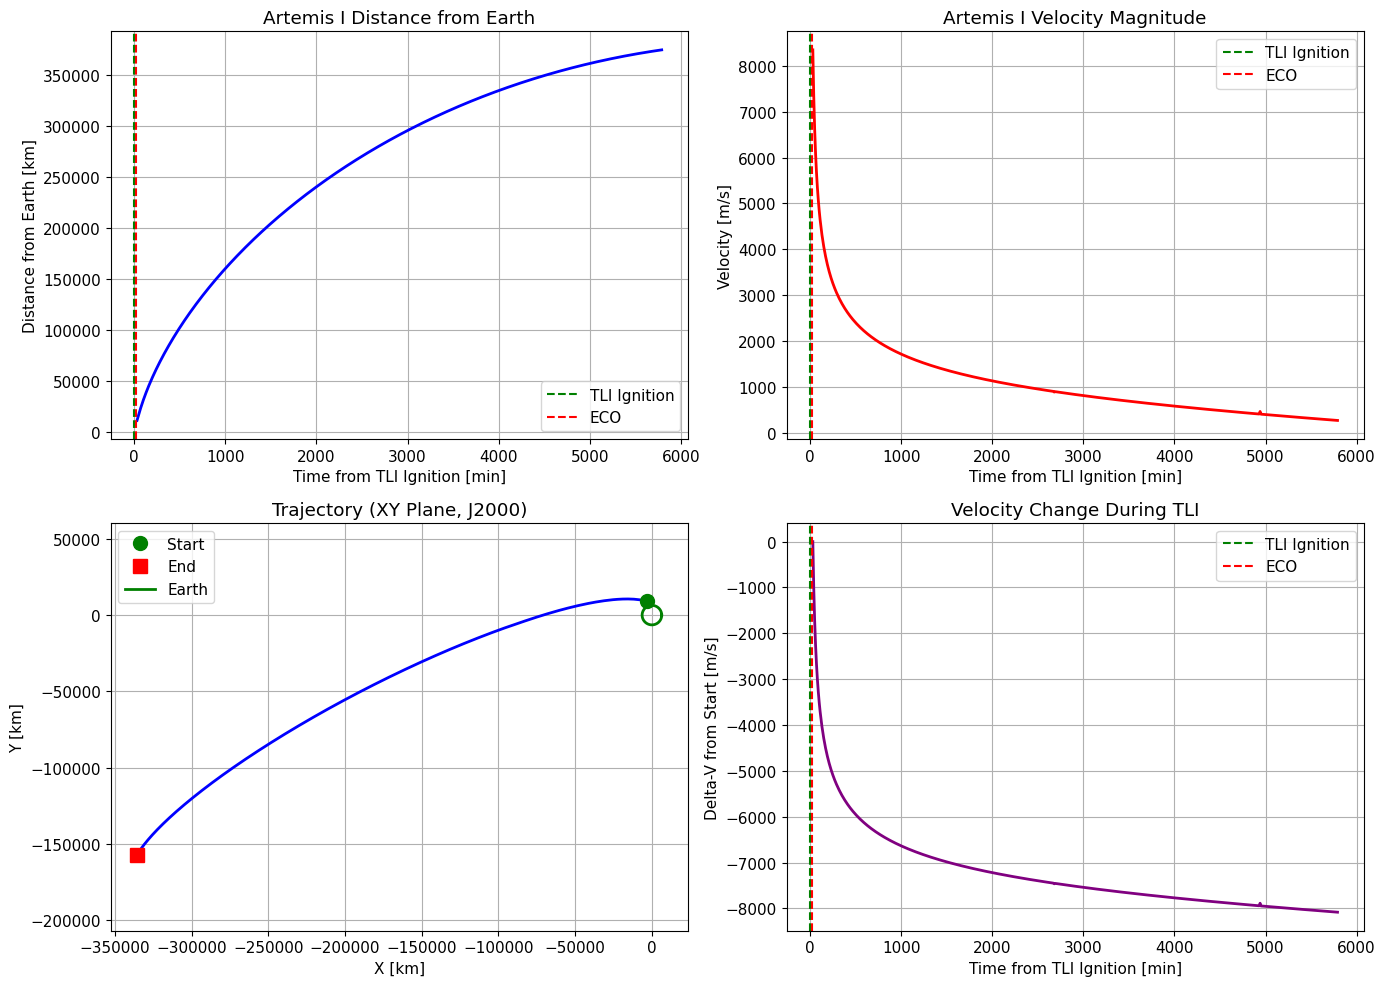


Total delta-V during window: -8083.8 m/s


In [8]:
# Plot the Horizons trajectory
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time relative to TLI start
t_rel = (horizons_data['times_et'] - tli_start_et) / 60.0  # minutes

# Position magnitude
ax = axes[0, 0]
r_mags = np.linalg.norm(horizons_data['positions'], axis=1)
ax.plot(t_rel, r_mags, 'b-', linewidth=2)
ax.axvline(0, color='g', linestyle='--', label='TLI Ignition')
ax.axvline(BURN_DURATION/60, color='r', linestyle='--', label='ECO')
ax.set_xlabel('Time from TLI Ignition [min]')
ax.set_ylabel('Distance from Earth [km]')
ax.set_title('Artemis I Distance from Earth')
ax.legend()

# Velocity magnitude
ax = axes[0, 1]
v_mags = np.linalg.norm(horizons_data['velocities'], axis=1)
ax.plot(t_rel, v_mags * 1000, 'r-', linewidth=2)  # Convert to m/s
ax.axvline(0, color='g', linestyle='--', label='TLI Ignition')
ax.axvline(BURN_DURATION/60, color='r', linestyle='--', label='ECO')
ax.set_xlabel('Time from TLI Ignition [min]')
ax.set_ylabel('Velocity [m/s]')
ax.set_title('Artemis I Velocity Magnitude')
ax.legend()

# XY trajectory
ax = axes[1, 0]
ax.plot(horizons_data['positions'][:, 0], horizons_data['positions'][:, 1], 'b-', linewidth=2)
ax.plot(horizons_data['positions'][0, 0], horizons_data['positions'][0, 1], 'go', markersize=10, label='Start')
ax.plot(horizons_data['positions'][-1, 0], horizons_data['positions'][-1, 1], 'rs', markersize=10, label='End')
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(R_EARTH * np.cos(theta), R_EARTH * np.sin(theta), 'g-', linewidth=2, label='Earth')
ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Trajectory (XY Plane, J2000)')
ax.axis('equal')
ax.legend()

# Delta-V accumulation (numerical derivative of velocity)
ax = axes[1, 1]
dv_accumulated = np.zeros(len(v_mags))
for i in range(1, len(v_mags)):
    dv_accumulated[i] = (v_mags[i] - v_mags[0]) * 1000  # m/s
ax.plot(t_rel, dv_accumulated, 'purple', linewidth=2)
ax.axvline(0, color='g', linestyle='--', label='TLI Ignition')
ax.axvline(BURN_DURATION/60, color='r', linestyle='--', label='ECO')
ax.set_xlabel('Time from TLI Ignition [min]')
ax.set_ylabel('Delta-V from Start [m/s]')
ax.set_title('Velocity Change During TLI')
ax.legend()

plt.tight_layout()
plt.savefig('../../data_output/artemis/plots/horizons_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal delta-V during window: {dv_accumulated[-1]:.1f} m/s")

## Two-Body Integrator (Model 0 Baseline)

The simplest dynamical model - point-mass Earth gravity only

$$\vec{a}_{2body} = -\frac{\mu_E}{r^3}\vec{r}$$

In [9]:
def accel_two_body(r, mu=MU_EARTH):
    """Compute two-body gravitational acceleration
    
    Args:
        r: Position vector [km] (3,)
        mu: Gravitational parameter [km^3/s^2]
    
    Returns:
        a: Acceleration vector [km/s^2] (3,)
    """
    r_mag = np.linalg.norm(r)
    return -mu * r / (r_mag ** 3)

In [10]:
def propagate_two_body(state0, t_span, t_eval=None, rtol=1e-10, atol=1e-12):
    """Propagate a 6-element state vector using two-body dynamics
    
    Args:
        state0: Initial state [x, y, z, vx, vy, vz] in km, km/s
        t_span: (t0, tf) time span in seconds
        t_eval: Times at which to store solution
        rtol, atol: Integrator tolerances
    
    Returns:
        Solution object from solve_ivp
    """
    def equations_of_motion(t, state):
        r = state[0:3]
        v = state[3:6]
        a = accel_two_body(r)
        return np.concatenate([v, a])
    
    sol = solve_ivp(
        equations_of_motion, 
        t_span, 
        state0, 
        method='RK45',
        t_eval=t_eval,
        rtol=rtol, 
        atol=atol,
        dense_output=True
    )
    return sol

In [11]:
# Test - propagate from first Horizons point to second without thrust
state0_test = np.concatenate([horizons_data['positions'][0], horizons_data['velocities'][0]])
dt_test = horizons_data['times_et'][1] - horizons_data['times_et'][0]

sol_test = propagate_two_body(state0_test, (0, dt_test))
state_pred = sol_test.y[:, -1]
state_actual = np.concatenate([horizons_data['positions'][1], horizons_data['velocities'][1]])

print("Two-body propagation validation (1-minute coast before TLI):")
print(f"  Position error: {np.linalg.norm(state_pred[0:3] - state_actual[0:3])*1000:.2f} m")
print(f"  Velocity error: {np.linalg.norm(state_pred[3:6] - state_actual[3:6])*1000:.4f} m/s")

Two-body propagation validation (1-minute coast before TLI):
  Position error: 448.85 m
  Velocity error: 1.1021 m/s


## Thrust Model with Mass Depletion (Model 1)

The 7 element state vector `[x, y, z, vx, vy, vz, m]` captures mass depletion during the burn

### Thrust Profile
- Exponential ramp-up: $T(t) = T_{nom}(1 - e^{-t/\tau})$ where $\tau \approx 1$ s
- Mass flow rate: $\frac{dm}{dt} = -\frac{T(t)}{I_{sp} \cdot g_0}$

### Assumption
Thrust vector aligned with velocity vector ($\hat{v}$).
(Real steering laws are more complex)

In [12]:
def thrust_profile(t, t_burn_start, t_burn_end, thrust_nominal=THRUST_NOMINAL, ramp_tau=1.0):
    """Compute thrust magnitude with startup transient.
    
    Args:
        t: Current time [s] (relative to simulation start)
        t_burn_start: Time when burn starts [s]
        t_burn_end: Time when burn ends [s]
        thrust_nominal: Nominal thrust [kN]
        ramp_tau: Time constant for exponential ramp [s]
    
    Returns:
        thrust: Thrust magnitude [kN]
    """
    if t < t_burn_start or t > t_burn_end:
        return 0.0
    
    t_since_ignition = t - t_burn_start
    
    # Exponential ramp-up
    ramp_factor = 1.0 - np.exp(-t_since_ignition / ramp_tau)
    
    return thrust_nominal * ramp_factor

In [13]:
def mass_flow_rate(thrust_kn, isp=ISP):
    """Compute mass flow rate from thrust.
    
    dm/dt = -T / (Isp * g0)
    
    Args:
        thrust_kn: Thrust in kN
        isp: Specific impulse [s]
    
    Returns:
        mdot: Mass flow rate [kg/s] (negative, mass is decreasing)
    """
    thrust_n = thrust_kn * 1000.0  # Convert to Newtons
    g0_si = 9.80665  # m/s^2
    return -thrust_n / (isp * g0_si)

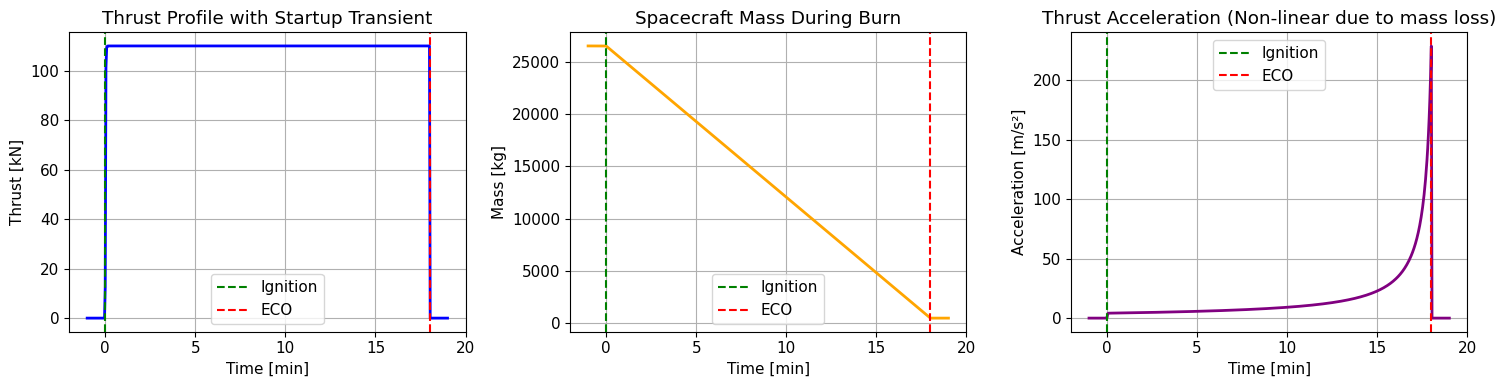

Initial mass: 26500 kg
Final mass: 480 kg
Propellant consumed: 26020 kg


In [14]:
# Visualize thrust profile and mass depletion
t_plot = np.linspace(-60, BURN_DURATION + 60, 500)
thrust_plot = [thrust_profile(t, 0, BURN_DURATION) for t in t_plot]

# Simulate mass depletion
mass_plot = [ORION_MASS_INITIAL]
dt_mass = t_plot[1] - t_plot[0]
for i in range(1, len(t_plot)):
    T = thrust_profile(t_plot[i], 0, BURN_DURATION)
    mdot = mass_flow_rate(T)
    mass_plot.append(mass_plot[-1] + mdot * dt_mass)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(t_plot / 60, thrust_plot, 'b-', linewidth=2)
ax.axvline(0, color='g', linestyle='--', label='Ignition')
ax.axvline(BURN_DURATION/60, color='r', linestyle='--', label='ECO')
ax.set_xlabel('Time [min]')
ax.set_ylabel('Thrust [kN]')
ax.set_title('Thrust Profile with Startup Transient')
ax.legend()

ax = axes[1]
ax.plot(t_plot / 60, mass_plot, 'orange', linewidth=2)
ax.axvline(0, color='g', linestyle='--', label='Ignition')
ax.axvline(BURN_DURATION/60, color='r', linestyle='--', label='ECO')
ax.set_xlabel('Time [min]')
ax.set_ylabel('Mass [kg]')
ax.set_title('Spacecraft Mass During Burn')
ax.legend()

# Acceleration = T/m
accel_plot = [thrust_plot[i] * 1000 / mass_plot[i] if mass_plot[i] > 0 else 0 for i in range(len(t_plot))]
ax = axes[2]
ax.plot(t_plot / 60, accel_plot, 'purple', linewidth=2)
ax.axvline(0, color='g', linestyle='--', label='Ignition')
ax.axvline(BURN_DURATION/60, color='r', linestyle='--', label='ECO')
ax.set_xlabel('Time [min]')
ax.set_ylabel('Acceleration [m/s²]')
ax.set_title('Thrust Acceleration (Non-linear due to mass loss)')
ax.legend()

plt.tight_layout()
plt.savefig('../../data_output/artemis/plots/thrust_profile.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Initial mass: {ORION_MASS_INITIAL:.0f} kg")
print(f"Final mass: {mass_plot[-1]:.0f} kg")
print(f"Propellant consumed: {ORION_MASS_INITIAL - mass_plot[-1]:.0f} kg")

In [15]:
def accel_thrust(v, mass, t, t_burn_start, t_burn_end):
    """Compute thrust acceleration aligned with velocity.
    
    Args:
        v: Velocity vector [km/s] (3,)
        mass: Spacecraft mass [kg]
        t: Current time [s]
        t_burn_start: Burn start time [s]
        t_burn_end: Burn end time [s]
    
    Returns:
        a: Acceleration vector [km/s^2] (3,)
    """
    T = thrust_profile(t, t_burn_start, t_burn_end)  # kN
    
    if T <= 0 or mass <= 0:
        return np.zeros(3)
    
    v_mag = np.linalg.norm(v)
    if v_mag < 1e-10:
        return np.zeros(3)
    
    v_hat = v / v_mag
    
    # T [kN] = T [N] / 1000, mass [kg]
    # a [km/s^2] = (T [N] / mass [kg]) / 1000
    a_mag = (T * 1000.0) / mass / 1000.0  # km/s^2
    
    return a_mag * v_hat

In [16]:
def propagate_with_thrust(state0, t_span, t_eval, t_burn_start, t_burn_end, 
                          gravity_func=accel_two_body, rtol=1e-10, atol=1e-12):
    """Propagate 7-element state with thrust and mass depletion.
    
    Args:
        state0: Initial state [x, y, z, vx, vy, vz, m] in km, km/s, kg
        t_span: (t0, tf) time span
        t_eval: Times to evaluate
        t_burn_start: Burn start time
        t_burn_end: Burn end time
        gravity_func: Function computing gravitational acceleration
        rtol, atol: Tolerances
    
    Returns:
        Solution object
    """
    def equations_of_motion(t, state):
        r = state[0:3]
        v = state[3:6]
        m = state[6]
        
        # Gravitational acceleration
        a_grav = gravity_func(r)
        
        # Thrust acceleration
        a_thrust = accel_thrust(v, m, t, t_burn_start, t_burn_end)
        
        # Total acceleration
        a_total = a_grav + a_thrust
        
        # Mass flow rate
        T = thrust_profile(t, t_burn_start, t_burn_end)
        mdot = mass_flow_rate(T)
        
        return np.concatenate([v, a_total, [mdot]])
    
    sol = solve_ivp(
        equations_of_motion,
        t_span,
        state0,
        method='RK45',
        t_eval=t_eval,
        rtol=rtol,
        atol=atol,
        dense_output=True
    )
    return sol


## J2 Oblateness Perturbation (Model 2)

Earth's equatorial bulge causes the J2 perturbation, the dominant non spherical gravity term:

$$\vec{a}_{J2} = -\frac{3}{2} J_2 \mu_E \frac{R_E^2}{r^5} \begin{bmatrix} x(5\frac{z^2}{r^2} - 1) \\ y(5\frac{z^2}{r^2} - 1) \\ z(5\frac{z^2}{r^2} - 3) \end{bmatrix}$$

where $J_2 = 1.08263 \times 10^{-3}$

In [17]:
def accel_j2(r, mu=MU_EARTH, j2=J2_EARTH, r_eq=R_EARTH):
    """Compute J2 oblateness perturbation acceleration.
    
    Args:
        r: Position vector [km] (3,)
        mu: Gravitational parameter [km^3/s^2]
        j2: J2 coefficient
        r_eq: Equatorial radius [km]
    
    Returns:
        a: J2 perturbation acceleration [km/s^2] (3,)
    """
    x, y, z = r
    r_mag = np.linalg.norm(r)
    r2 = r_mag ** 2
    r5 = r_mag ** 5
    
    z2_r2 = (z ** 2) / r2
    
    coeff = -1.5 * j2 * mu * (r_eq ** 2) / r5
    
    a_x = coeff * x * (5 * z2_r2 - 1)
    a_y = coeff * y * (5 * z2_r2 - 1)
    a_z = coeff * z * (5 * z2_r2 - 3)
    
    return np.array([a_x, a_y, a_z])


In [18]:
def accel_two_body_j2(r):
    """Combined two-body + J2 acceleration."""
    return accel_two_body(r) + accel_j2(r)

In [19]:
# Test J2 magnitude at typical TLI altitude
r_test = horizons_data['positions'][0]
a_2body = accel_two_body(r_test)
a_j2 = accel_j2(r_test)

print("Acceleration comparison at initial position:")
print(f"  Two-body: {np.linalg.norm(a_2body)*1000:.6f} m/s² ({np.linalg.norm(a_2body)*1e6:.3f} mm/s²)")
print(f"  J2:       {np.linalg.norm(a_j2)*1e6:.6f} mm/s²")
print(f"  J2/2body ratio: {np.linalg.norm(a_j2)/np.linalg.norm(a_2body)*100:.4f}%")

Acceleration comparison at initial position:
  Two-body: 3.229358 m/s² (3229.358 mm/s²)
  J2:       1.559640 mm/s²
  J2/2body ratio: 0.0483%


## Third-Body Perturbations (Models 3-4)

Moon and Sun gravity make this an n-body problem, 3rd body acc. uses the indirect term:

$$\vec{a}_{3B} = \mu_{body}\left(\frac{\vec{r}_{body \to s/c}}{|\vec{r}_{body \to s/c}|^3} - \frac{\vec{r}_{body \to Earth}}{|\vec{r}_{body \to Earth}|^3}\right)$$

SPICE provides precise planetary positions
(times in ET, not UTC)

In [20]:
def get_body_position_spice(body_id, observer_id, et):
    """Get body position from SPICE.
    
    Args:
        body_id: NAIF ID of target body (301=Moon, 10=Sun)
        observer_id: NAIF ID of observer (399=Earth)
        et: Ephemeris time [s past J2000]
    
    Returns:
        r: Position vector [km] (3,)
    """
    state, lt = spice.spkgeo(targ=body_id, et=et, ref='J2000', obs=observer_id)
    return np.array(state[:3])


In [21]:
def accel_third_body(r_sc, r_body, mu_body):
    """Compute third-body gravitational perturbation.
    
    Args:
        r_sc: Spacecraft position wrt central body [km] (3,)
        r_body: Third body position wrt central body [km] (3,)
        mu_body: Third body gravitational parameter [km^3/s^2]
    
    Returns:
        a: Third-body perturbation acceleration [km/s^2] (3,)
    """
    # Vector from third body to spacecraft
    r_body_to_sc = r_sc - r_body
    r_body_to_sc_mag = np.linalg.norm(r_body_to_sc)
    
    # Vector from third body to central body (Earth)
    r_body_to_earth = -r_body
    r_body_to_earth_mag = np.linalg.norm(r_body_to_earth)
    
    # Direct term (pull on spacecraft) + indirect term (pull on central body)
    a = mu_body * (r_body_to_sc / r_body_to_sc_mag**3 - r_body / r_body_to_earth_mag**3)
    
    # Note: The indirect term accounts for the fact that Earth is also
    # being accelerated by the third body
    return -a  # Negative because we want acceleration toward the body

In [22]:
def accel_moon(r_sc, et):
    """Moon third-body perturbation."""
    r_moon = get_body_position_spice(301, 399, et)  # Moon wrt Earth
    return accel_third_body(r_sc, r_moon, MU_MOON)


def accel_sun(r_sc, et):
    """Sun third-body perturbation."""
    r_sun = get_body_position_spice(10, 399, et)  # Sun wrt Earth
    return accel_third_body(r_sc, r_sun, MU_SUN)

In [23]:
# Test third-body accelerations at TLI
et_test = utc_to_et(TLI_START_UTC)
r_test = horizons_data['positions'][idx_ignition]

a_moon = accel_moon(r_test, et_test)
a_sun = accel_sun(r_test, et_test)

print("Third-body accelerations at TLI ignition:")
print(f"  Moon: {np.linalg.norm(a_moon)*1e9:.3f} nm/s² (direction: [{a_moon[0]/np.linalg.norm(a_moon):.3f}, {a_moon[1]/np.linalg.norm(a_moon):.3f}, {a_moon[2]/np.linalg.norm(a_moon):.3f}])")
print(f"  Sun:  {np.linalg.norm(a_sun)*1e9:.3f} nm/s²")
print(f"  Moon/J2 ratio: {np.linalg.norm(a_moon)/np.linalg.norm(accel_j2(r_test))*100:.4f}%")

# Moon position check
r_moon = get_body_position_spice(301, 399, et_test)
print(f"\nMoon distance from Earth: {np.linalg.norm(r_moon):.0f} km")

Third-body accelerations at TLI ignition:
  Moon: 62.027 nm/s² (direction: [-0.782, 0.530, 0.328])
  Sun:  12124.731 nm/s²
  Moon/J2 ratio: 3.9770%

Moon distance from Earth: 402232 km


## Solar Radiation Pressure (Model 5)

The cannonball SRP model assumes a spherical spacecraft:

$$\vec{a}_{SRP} = -C_r \frac{A}{m} \frac{\Phi}{c} \left(\frac{1 AU}{r_{sun}}\right)^2 \hat{s}$$

where $\hat{s}$ is the unit vector from spacecraft to Sun.

Eclipse shadowing is included (SRP = 0 when spacecraft is in Earth's shadow).

In [24]:
def is_in_shadow(r_sc, r_sun, r_body=R_EARTH):
    """Check if spacecraft is in Earth's shadow (cylindrical model).
    
    Args:
        r_sc: Spacecraft position wrt Earth [km]
        r_sun: Sun position wrt Earth [km]
        r_body: Shadow-casting body radius [km]
    
    Returns:
        shadow_factor: 1.0 = full sun, 0.0 = full shadow
    """
    # Unit vector from Earth to Sun
    r_sun_mag = np.linalg.norm(r_sun)
    sun_hat = r_sun / r_sun_mag
    
    # Project spacecraft position onto Sun direction
    proj = np.dot(r_sc, sun_hat)
    
    # If spacecraft is on Sun side, not in shadow
    if proj > 0:
        return 1.0
    
    # Perpendicular distance from shadow axis
    perp = r_sc - proj * sun_hat
    perp_dist = np.linalg.norm(perp)
    
    # Simple cylindrical shadow
    if perp_dist < r_body:
        return 0.0
    
    return 1.0

In [25]:
def accel_srp(r_sc, mass, et, cr=CR_SRP, area=ORION_AREA):
    """Compute Solar Radiation Pressure acceleration (cannonball model).
    
    Args:
        r_sc: Spacecraft position wrt Earth [km]
        mass: Spacecraft mass [kg]
        et: Ephemeris time
        cr: Reflectivity coefficient
        area: Cross-sectional area [m^2]
    
    Returns:
        a: SRP acceleration [km/s^2]
    """
    # Sun position wrt Earth
    r_sun_earth = get_body_position_spice(10, 399, et)
    
    # Spacecraft to Sun vector
    r_sc_to_sun = r_sun_earth - r_sc
    r_sc_sun_mag = np.linalg.norm(r_sc_to_sun)
    sun_hat = r_sc_to_sun / r_sc_sun_mag
    
    # Check shadow
    shadow = is_in_shadow(r_sc, r_sun_earth)
    if shadow == 0:
        return np.zeros(3)
    
    # SRP pressure at 1 AU: P = Phi/c
    # Phi = 1367 W/m^2, c = 299792458 m/s
    # P_1AU = 1367 / 299792458 = 4.56e-6 N/m^2
    P_1AU = SOLAR_FLUX / (C_LIGHT * 1000)  # N/m^2 (c in m/s)
    
    # Scale by distance
    r_sc_sun_au = r_sc_sun_mag / AU_KM
    P = P_1AU / (r_sc_sun_au ** 2)
    
    # Acceleration: a = Cr * P * A / m
    # Units: a [m/s^2] = Cr * P [N/m^2] * A [m^2] / m [kg]
    a_mag = cr * P * area / mass  # m/s^2
    a_mag_km = a_mag / 1000.0  # km/s^2
    
    # Direction: away from Sun
    return -a_mag_km * sun_hat * shadow

In [26]:
a_srp_test = accel_srp(r_test, ORION_MASS_INITIAL, et_test)
print(f"SRP acceleration at TLI: {np.linalg.norm(a_srp_test)*1e12:.3f} pm/s²")
print(f"SRP/Moon ratio: {np.linalg.norm(a_srp_test)/np.linalg.norm(a_moon)*100:.4f}%")
print(f"Shadow factor: {is_in_shadow(r_test, get_body_position_spice(10, 399, et_test))}")

SRP acceleration at TLI: 6.596 pm/s²
SRP/Moon ratio: 0.0106%
Shadow factor: 1.0


## Unified Propagator with All Models

enable/disable each perturbation source

In [27]:
class TLIPropagator:
    """Unified propagator for TLI simulation with configurable perturbations."""
    
    def __init__(self, et_start, include_j2=False, include_moon=False, 
                 include_sun=False, include_srp=False, include_thrust=True,
                 t_burn_start=0, t_burn_end=BURN_DURATION):
        """
        Args:
            et_start: Ephemeris time at simulation start
            include_j2: Include J2 oblateness
            include_moon: Include Moon third-body
            include_sun: Include Sun third-body
            include_srp: Include solar radiation pressure
            include_thrust: Include thrust (False for coast)
            t_burn_start: Burn start time relative to sim start [s]
            t_burn_end: Burn end time relative to sim start [s]
        """
        self.et_start = et_start
        self.include_j2 = include_j2
        self.include_moon = include_moon
        self.include_sun = include_sun
        self.include_srp = include_srp
        self.include_thrust = include_thrust
        self.t_burn_start = t_burn_start
        self.t_burn_end = t_burn_end
        
        # For tracking acceleration contributions
        self.accel_history = {
            'two_body': [], 'j2': [], 'moon': [], 'sun': [], 'srp': [], 'thrust': []
        }
    
    def compute_acceleration(self, t, r, v, m):
        """Compute total acceleration with all enabled perturbations."""
        et = self.et_start + t
        
        # Two-body (always included)
        a_2body = accel_two_body(r)
        a_total = a_2body.copy()
        
        # J2
        a_j2 = np.zeros(3)
        if self.include_j2:
            a_j2 = accel_j2(r)
            a_total += a_j2
        
        # Moon
        a_moon = np.zeros(3)
        if self.include_moon:
            a_moon = accel_moon(r, et)
            a_total += a_moon
        
        # Sun
        a_sun = np.zeros(3)
        if self.include_sun:
            a_sun = accel_sun(r, et)
            a_total += a_sun
        
        # SRP
        a_srp = np.zeros(3)
        if self.include_srp:
            a_srp = accel_srp(r, m, et)
            a_total += a_srp
        
        # Thrust
        a_thrust = np.zeros(3)
        if self.include_thrust:
            a_thrust = accel_thrust(v, m, t, self.t_burn_start, self.t_burn_end)
            a_total += a_thrust
        
        return a_total, {
            'two_body': a_2body, 'j2': a_j2, 'moon': a_moon,
            'sun': a_sun, 'srp': a_srp, 'thrust': a_thrust
        }
    
    def equations_of_motion(self, t, state):
        """7-DOF equations of motion for solve_ivp."""
        r = state[0:3]
        v = state[3:6]
        m = state[6]
        
        a_total, _ = self.compute_acceleration(t, r, v, m)
        
        # Mass flow rate
        if self.include_thrust:
            T = thrust_profile(t, self.t_burn_start, self.t_burn_end)
            mdot = mass_flow_rate(T)
        else:
            mdot = 0.0
        
        return np.concatenate([v, a_total, [mdot]])
    
    def propagate(self, state0, t_span, t_eval=None, rtol=1e-10, atol=1e-12):
        """Propagate the 7-element state vector."""
        sol = solve_ivp(
            self.equations_of_motion,
            t_span,
            state0,
            method='RK45',
            t_eval=t_eval,
            rtol=rtol,
            atol=atol,
            dense_output=True
        )
        return sol


print("TLIPropagator class defined.")

TLIPropagator class defined.


## Run All Models and Compare

In [28]:
# Define model configurations
MODEL_CONFIGS = {
    'Model 0: 2-body only (no thrust)': {
        'include_j2': False, 'include_moon': False, 'include_sun': False,
        'include_srp': False, 'include_thrust': False
    },
    'Model 1: 2-body + thrust': {
        'include_j2': False, 'include_moon': False, 'include_sun': False,
        'include_srp': False, 'include_thrust': True
    },
    'Model 2: + J2': {
        'include_j2': True, 'include_moon': False, 'include_sun': False,
        'include_srp': False, 'include_thrust': True
    },
    'Model 3: + Moon': {
        'include_j2': True, 'include_moon': True, 'include_sun': False,
        'include_srp': False, 'include_thrust': True
    },
    'Model 4: + Sun': {
        'include_j2': True, 'include_moon': True, 'include_sun': True,
        'include_srp': False, 'include_thrust': True
    },
    'Model 5: + SRP (Full)': {
        'include_j2': True, 'include_moon': True, 'include_sun': True,
        'include_srp': True, 'include_thrust': True
    },
}

# Initial conditions from Horizons at TLI ignition
r0_tli = horizons_data['positions'][idx_ignition]
v0_tli = horizons_data['velocities'][idx_ignition]
state0_7 = np.concatenate([r0_tli, v0_tli, [ORION_MASS_INITIAL]])

# Time span: from TLI ignition to end of window
et_ignition = horizons_data['times_et'][idx_ignition]
t_total = horizons_data['times_et'][-1] - et_ignition
t_eval = horizons_data['times_et'][idx_ignition:] - et_ignition

print(f"Simulation setup:")
print(f"  Initial position: {r0_tli} km")
print(f"  Initial velocity: {v0_tli} km/s")
print(f"  Initial mass: {ORION_MASS_INITIAL} kg")
print(f"  Simulation duration: {t_total:.1f} s ({t_total/60:.1f} min)")
print(f"  ET at ignition: {et_ignition:.3f}")

Simulation setup:
  Initial position: [-3171.29585472  9061.16221995  5591.82213079] km
  Initial velocity: [-7.76325581  2.22221349  2.12251486] km/s
  Initial mass: 26500.0 kg
  Simulation duration: 345600.0 s (5760.0 min)
  ET at ignition: 721860489.183


In [29]:
# Run all models
results = {}

for model_name, config in MODEL_CONFIGS.items():
    print(f"\nRunning {model_name}...")
    
    propagator = TLIPropagator(
        et_start=et_ignition,
        t_burn_start=0,
        t_burn_end=BURN_DURATION,
        **config
    )
    
    sol = propagator.propagate(state0_7, (0, t_total), t_eval=t_eval)
    
    if sol.success:
        results[model_name] = {
            'times': sol.t,
            'positions': sol.y[0:3, :].T,
            'velocities': sol.y[3:6, :].T,
            'masses': sol.y[6, :],
            'config': config
        }
        print(f"  Success! Final position error check coming...")
    else:
        print(f"  FAILED: {sol.message}")

print("\n" + "="*60)
print("All simulations complete!")


Running Model 0: 2-body only (no thrust)...
  Success! Final position error check coming...

Running Model 1: 2-body + thrust...
  Success! Final position error check coming...

Running Model 2: + J2...
  Success! Final position error check coming...

Running Model 3: + Moon...
  Success! Final position error check coming...

Running Model 4: + Sun...
  Success! Final position error check coming...

Running Model 5: + SRP (Full)...
  Success! Final position error check coming...

All simulations complete!


### Error Metrics Computation

Compute position and velocity errors relative to Horizons. Decompose into Radial, Along-track, and Cross-track (RIC) components.

In [30]:
def compute_ric_components(r_true, v_true, r_sim):
    """Decompose position error into Radial, In-track (along-track), Cross-track.
    
    Args:
        r_true: True position vector [km]
        v_true: True velocity vector [km/s]
        r_sim: Simulated position vector [km]
    
    Returns:
        radial, along_track, cross_track errors [km]
    """
    # Error vector
    dr = r_sim - r_true
    
    # RIC frame unit vectors
    r_hat = r_true / np.linalg.norm(r_true)  # Radial
    h = np.cross(r_true, v_true)  # Angular momentum
    c_hat = h / np.linalg.norm(h)  # Cross-track (normal)
    i_hat = np.cross(c_hat, r_hat)  # In-track (along-track)
    
    # Project error onto RIC
    radial = np.dot(dr, r_hat)
    along_track = np.dot(dr, i_hat)
    cross_track = np.dot(dr, c_hat)
    
    return radial, along_track, cross_track


def compute_errors(model_result, horizons_data, idx_start):
    """Compute error metrics for a model result."""
    n_points = len(model_result['times'])
    
    errors = {
        'times': model_result['times'],
        'pos_error': np.zeros(n_points),
        'vel_error': np.zeros(n_points),
        'radial': np.zeros(n_points),
        'along_track': np.zeros(n_points),
        'cross_track': np.zeros(n_points)
    }
    
    for i in range(n_points):
        r_true = horizons_data['positions'][idx_start + i]
        v_true = horizons_data['velocities'][idx_start + i]
        r_sim = model_result['positions'][i]
        v_sim = model_result['velocities'][i]
        
        # Total errors
        errors['pos_error'][i] = np.linalg.norm(r_sim - r_true)
        errors['vel_error'][i] = np.linalg.norm(v_sim - v_true)
        
        # RIC decomposition
        r, a, c = compute_ric_components(r_true, v_true, r_sim)
        errors['radial'][i] = r
        errors['along_track'][i] = a
        errors['cross_track'][i] = c
    
    return errors


# Compute errors for all models
all_errors = {}
for model_name, result in results.items():
    all_errors[model_name] = compute_errors(result, horizons_data, idx_ignition)

# Summary table at Engine Cutoff (ECO)
eco_idx = np.argmin(np.abs(t_eval - BURN_DURATION))

print("\n" + "="*80)
print("ERROR SUMMARY AT ENGINE CUTOFF (ECO)")
print("="*80)
print(f"{'Model':<35} {'Pos Error [km]':>15} {'Vel Error [m/s]':>15}")
print("-"*80)

for model_name, errors in all_errors.items():
    pos_err = errors['pos_error'][eco_idx]
    vel_err = errors['vel_error'][eco_idx] * 1000  # Convert to m/s
    print(f"{model_name:<35} {pos_err:>15.3f} {vel_err:>15.3f}")

print("-"*80)


ERROR SUMMARY AT ENGINE CUTOFF (ECO)
Model                                Pos Error [km] Vel Error [m/s]
--------------------------------------------------------------------------------
Model 0: 2-body only (no thrust)              1.041           1.013
Model 1: 2-body + thrust                   6764.323       18276.900
Model 2: + J2                              6764.396       18277.011
Model 3: + Moon                            6764.438       18277.083
Model 4: + Sun                             6767.324       18281.984
Model 5: + SRP (Full)                      6767.324       18281.983
--------------------------------------------------------------------------------


### Error Evolution Plots

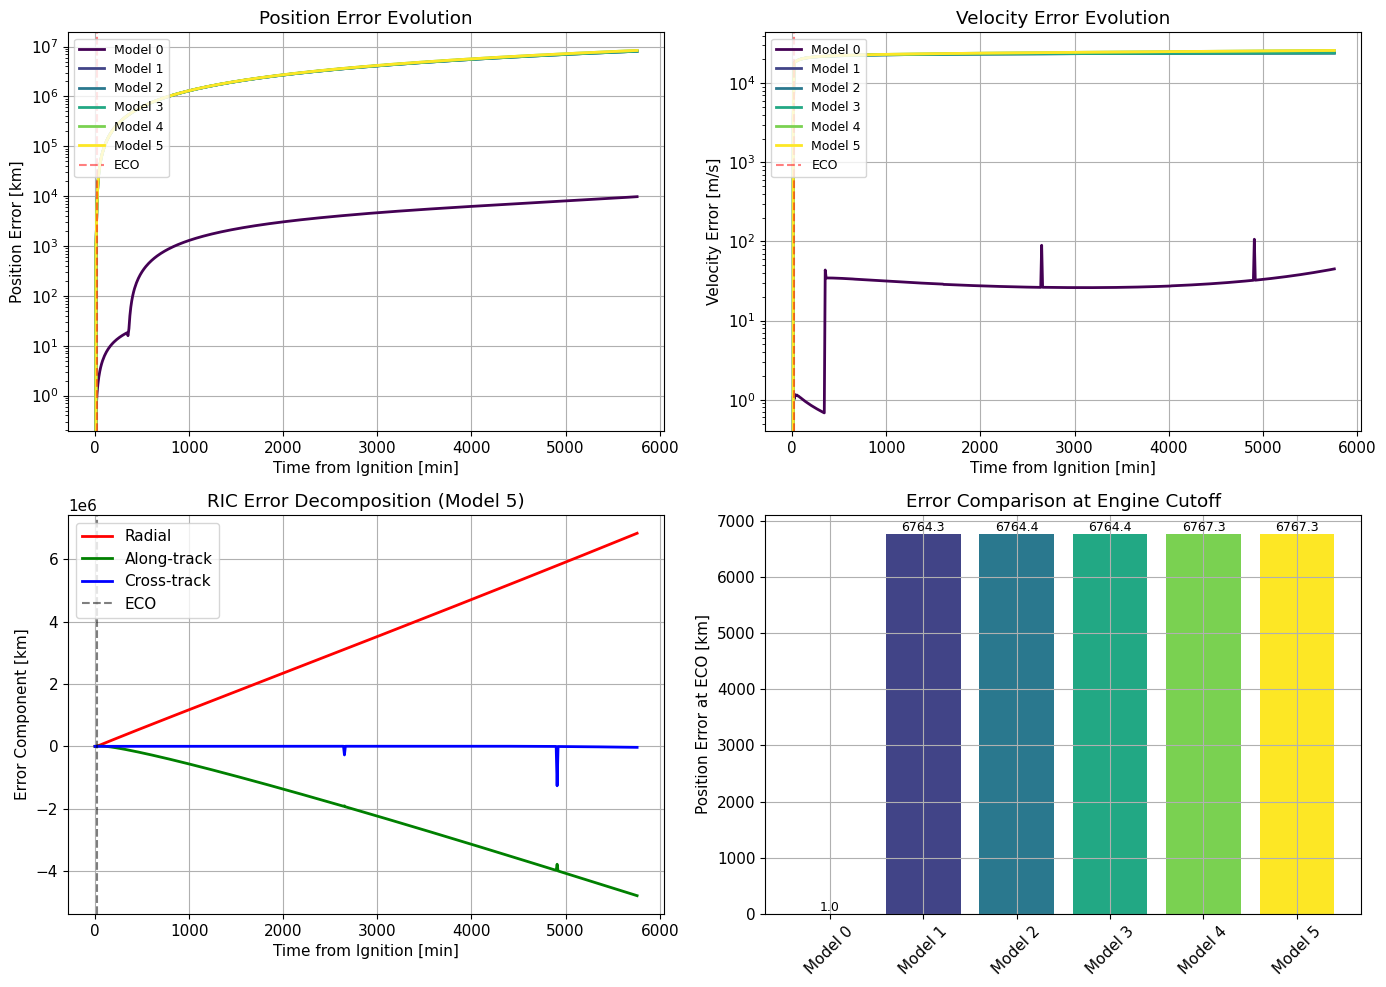

In [31]:
# Plot error evolution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = plt.cm.viridis(np.linspace(0, 1, len(results)))

# Position error
ax = axes[0, 0]
for (model_name, errors), color in zip(all_errors.items(), colors):
    t_min = errors['times'] / 60
    ax.plot(t_min, errors['pos_error'], label=model_name.split(':')[0], color=color, linewidth=2)
ax.axvline(BURN_DURATION/60, color='r', linestyle='--', alpha=0.5, label='ECO')
ax.set_xlabel('Time from Ignition [min]')
ax.set_ylabel('Position Error [km]')
ax.set_title('Position Error Evolution')
ax.legend(loc='upper left', fontsize=9)
ax.set_yscale('log')

# Velocity error
ax = axes[0, 1]
for (model_name, errors), color in zip(all_errors.items(), colors):
    t_min = errors['times'] / 60
    ax.plot(t_min, errors['vel_error'] * 1000, label=model_name.split(':')[0], color=color, linewidth=2)
ax.axvline(BURN_DURATION/60, color='r', linestyle='--', alpha=0.5, label='ECO')
ax.set_xlabel('Time from Ignition [min]')
ax.set_ylabel('Velocity Error [m/s]')
ax.set_title('Velocity Error Evolution')
ax.legend(loc='upper left', fontsize=9)
ax.set_yscale('log')

# RIC decomposition for best model (Model 5)
best_model = 'Model 5: + SRP (Full)'
ax = axes[1, 0]
t_min = all_errors[best_model]['times'] / 60
ax.plot(t_min, all_errors[best_model]['radial'], 'r-', label='Radial', linewidth=2)
ax.plot(t_min, all_errors[best_model]['along_track'], 'g-', label='Along-track', linewidth=2)
ax.plot(t_min, all_errors[best_model]['cross_track'], 'b-', label='Cross-track', linewidth=2)
ax.axvline(BURN_DURATION/60, color='k', linestyle='--', alpha=0.5, label='ECO')
ax.set_xlabel('Time from Ignition [min]')
ax.set_ylabel('Error Component [km]')
ax.set_title(f'RIC Error Decomposition ({best_model.split(":")[0]})')
ax.legend()

# Error at ECO bar chart
ax = axes[1, 1]
model_names_short = [m.split(':')[0] for m in all_errors.keys()]
eco_errors = [all_errors[m]['pos_error'][eco_idx] for m in all_errors.keys()]
bars = ax.bar(model_names_short, eco_errors, color=colors)
ax.set_ylabel('Position Error at ECO [km]')
ax.set_title('Error Comparison at Engine Cutoff')
ax.tick_params(axis='x', rotation=45)
for bar, err in zip(bars, eco_errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{err:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../../data_output/artemis/plots/error_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

### Trajectory Comparison

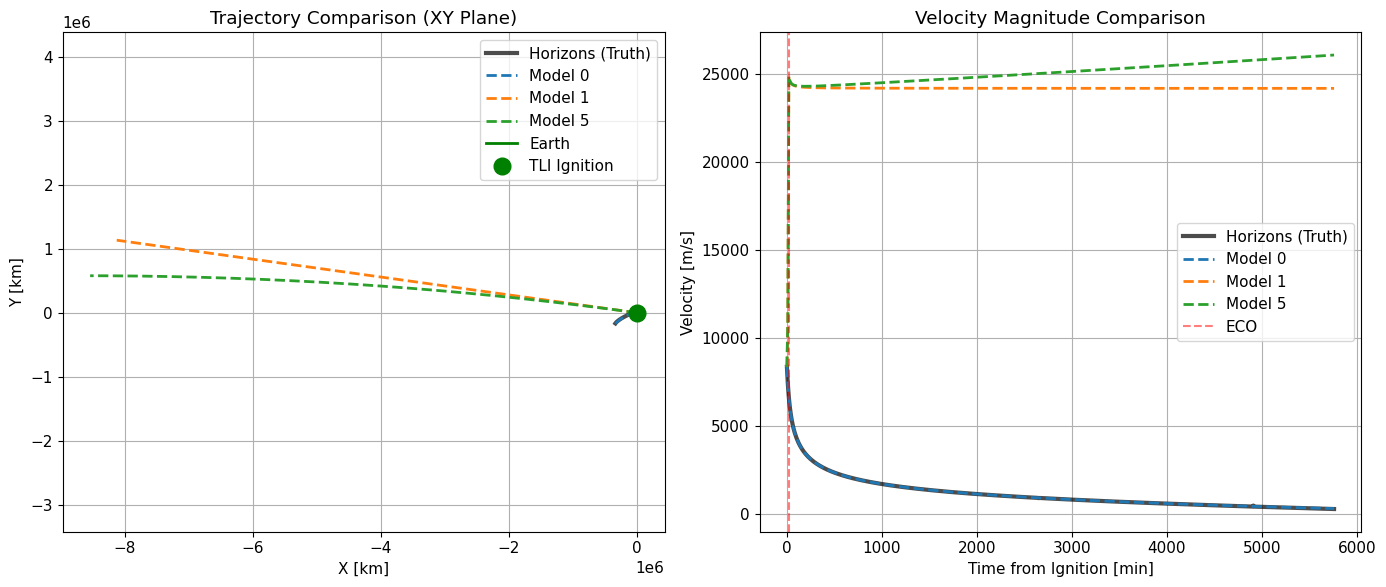

In [32]:
# Trajectory comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XY plane
ax = axes[0]
# Horizons (truth)
ax.plot(horizons_data['positions'][idx_ignition:, 0], 
        horizons_data['positions'][idx_ignition:, 1], 
        'k-', linewidth=3, label='Horizons (Truth)', alpha=0.7)

# Selected models
for model_name in ['Model 0: 2-body only (no thrust)', 'Model 1: 2-body + thrust', 'Model 5: + SRP (Full)']:
    if model_name in results:
        ax.plot(results[model_name]['positions'][:, 0],
                results[model_name]['positions'][:, 1],
                '--', linewidth=2, label=model_name.split(':')[0])

# Earth
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(R_EARTH * np.cos(theta), R_EARTH * np.sin(theta), 'g-', linewidth=2, label='Earth')
ax.plot(r0_tli[0], r0_tli[1], 'go', markersize=12, label='TLI Ignition')

ax.set_xlabel('X [km]')
ax.set_ylabel('Y [km]')
ax.set_title('Trajectory Comparison (XY Plane)')
ax.axis('equal')
ax.legend()

# Velocity magnitude comparison
ax = axes[1]
t_min = (horizons_data['times_et'][idx_ignition:] - horizons_data['times_et'][idx_ignition]) / 60

# Horizons
v_mag_horizons = np.linalg.norm(horizons_data['velocities'][idx_ignition:], axis=1) * 1000
ax.plot(t_min, v_mag_horizons, 'k-', linewidth=3, label='Horizons (Truth)', alpha=0.7)

# Models
for model_name, result in results.items():
    if 'thrust' in model_name.lower() or 'Model 1' in model_name or 'Model 5' in model_name:
        v_mag = np.linalg.norm(result['velocities'], axis=1) * 1000
        ax.plot(result['times']/60, v_mag, '--', linewidth=2, label=model_name.split(':')[0])

ax.axvline(BURN_DURATION/60, color='r', linestyle='--', alpha=0.5, label='ECO')
ax.set_xlabel('Time from Ignition [min]')
ax.set_ylabel('Velocity [m/s]')
ax.set_title('Velocity Magnitude Comparison')
ax.legend()

plt.tight_layout()
plt.savefig('../../data_output/artemis/plots/trajectory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Acceleration Breakdown During TLI

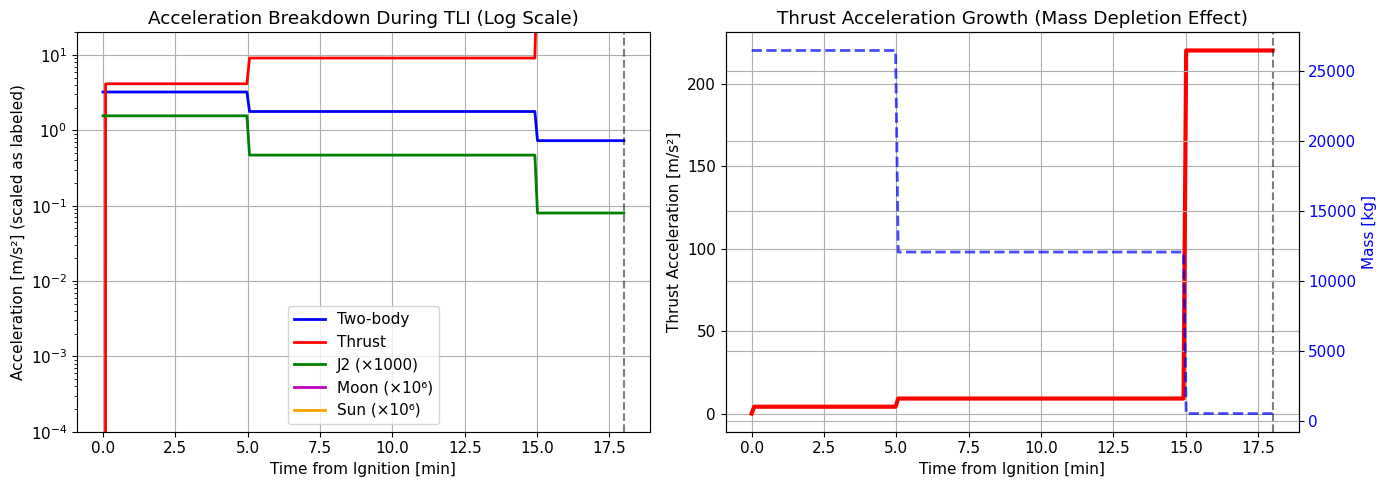


Typical Acceleration Magnitudes During TLI:
  Two-body:  2.0068 m/s²
  Thrust:    43.5573 m/s²
  J2:        0.7084 μm/s²
  Moon:      62.9323 nm/s²
  Sun:       12125.0399 nm/s²


In [33]:
# Compute acceleration breakdown over time
t_accel = np.linspace(0, BURN_DURATION, 200)
accel_breakdown = {
    'two_body': [], 'j2': [], 'moon': [], 'sun': [], 'srp': [], 'thrust': []
}

# Use the full model to get all accelerations
propagator_full = TLIPropagator(
    et_start=et_ignition,
    include_j2=True, include_moon=True, include_sun=True,
    include_srp=True, include_thrust=True,
    t_burn_start=0, t_burn_end=BURN_DURATION
)

# Simulate mass depletion for acceleration calculation
mass_sim = ORION_MASS_INITIAL
for t in t_accel:
    # Interpolate position from results
    idx = np.argmin(np.abs(results['Model 5: + SRP (Full)']['times'] - t))
    r = results['Model 5: + SRP (Full)']['positions'][idx]
    v = results['Model 5: + SRP (Full)']['velocities'][idx]
    m = results['Model 5: + SRP (Full)']['masses'][idx]
    
    _, accel_components = propagator_full.compute_acceleration(t, r, v, m)
    
    for key in accel_breakdown:
        accel_breakdown[key].append(np.linalg.norm(accel_components[key]))

# Convert to arrays
for key in accel_breakdown:
    accel_breakdown[key] = np.array(accel_breakdown[key])

# Plot acceleration breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All accelerations
ax = axes[0]
ax.semilogy(t_accel/60, accel_breakdown['two_body']*1000, 'b-', linewidth=2, label='Two-body')
ax.semilogy(t_accel/60, accel_breakdown['thrust']*1000, 'r-', linewidth=2, label='Thrust')
ax.semilogy(t_accel/60, accel_breakdown['j2']*1e6, 'g-', linewidth=2, label='J2 (×1000)')
ax.semilogy(t_accel/60, accel_breakdown['moon']*1e9, 'm-', linewidth=2, label='Moon (×10⁶)')
ax.semilogy(t_accel/60, accel_breakdown['sun']*1e9, 'orange', linewidth=2, label='Sun (×10⁶)')
ax.axvline(BURN_DURATION/60, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('Time from Ignition [min]')
ax.set_ylabel('Acceleration [m/s²] (scaled as labeled)')
ax.set_title('Acceleration Breakdown During TLI (Log Scale)')
ax.legend()
ax.set_ylim([1e-4, 20])

# Thrust acceleration growth due to mass loss
ax = axes[1]
ax.plot(t_accel/60, accel_breakdown['thrust']*1000, 'r-', linewidth=3)
ax.axvline(BURN_DURATION/60, color='k', linestyle='--', alpha=0.5, label='ECO')
ax.set_xlabel('Time from Ignition [min]')
ax.set_ylabel('Thrust Acceleration [m/s²]')
ax.set_title('Thrust Acceleration Growth (Mass Depletion Effect)')

# Add mass on secondary axis
ax2 = ax.twinx()
mass_interp = [results['Model 5: + SRP (Full)']['masses'][np.argmin(np.abs(results['Model 5: + SRP (Full)']['times'] - t))] 
               for t in t_accel]
ax2.plot(t_accel/60, mass_interp, 'b--', linewidth=2, alpha=0.7)
ax2.set_ylabel('Mass [kg]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.tight_layout()
plt.savefig('../../data_output/artemis/plots/acceleration_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

# Print typical magnitudes
print("\nTypical Acceleration Magnitudes During TLI:")
print(f"  Two-body:  {np.mean(accel_breakdown['two_body'])*1000:.4f} m/s²")
print(f"  Thrust:    {np.mean(accel_breakdown['thrust'])*1000:.4f} m/s²")
print(f"  J2:        {np.mean(accel_breakdown['j2'])*1e6:.4f} μm/s²")
print(f"  Moon:      {np.mean(accel_breakdown['moon'])*1e9:.4f} nm/s²")
print(f"  Sun:       {np.mean(accel_breakdown['sun'])*1e9:.4f} nm/s²")

## Technical Analysis: Error Sources and Perturbation Contributions

### Why Does the Model Drift from Reality?

The simulation error at Engine Cutoff (ECO) reflects the cumulative effect of modeling simplifications. Here we quantify each contributor

In [34]:
# Quantify the contribution of each perturbation to error reduction
print("="*80)
print("PERTURBATION CONTRIBUTION ANALYSIS")
print("="*80)
print("\nError reduction when adding each perturbation:\n")

models_ordered = [
    'Model 0: 2-body only (no thrust)',
    'Model 1: 2-body + thrust',
    'Model 2: + J2',
    'Model 3: + Moon',
    'Model 4: + Sun',
    'Model 5: + SRP (Full)'
]

prev_error = None
contributions = []

for i, model_name in enumerate(models_ordered):
    if model_name in all_errors:
        current_error = all_errors[model_name]['pos_error'][eco_idx]
        
        if prev_error is not None:
            reduction = prev_error - current_error
            reduction_pct = (reduction / prev_error) * 100 if prev_error > 0 else 0
            contributions.append({
                'transition': f"{models_ordered[i-1].split(':')[0]} → {model_name.split(':')[0]}",
                'reduction_km': reduction,
                'reduction_pct': reduction_pct
            })
            print(f"  {models_ordered[i-1].split(':')[0]:>10} → {model_name.split(':')[0]:<15}: "
                  f"{reduction:>+10.3f} km ({reduction_pct:>+6.2f}%)")
        else:
            print(f"  {'Baseline':>10} {model_name.split(':')[0]:<15}: {current_error:>10.3f} km")
        
        prev_error = current_error

print("\n" + "-"*80)

PERTURBATION CONTRIBUTION ANALYSIS

Error reduction when adding each perturbation:

    Baseline Model 0        :      1.041 km
     Model 0 → Model 1        :  -6763.282 km (-649816.89%)
     Model 1 → Model 2        :     -0.073 km ( -0.00%)
     Model 2 → Model 3        :     -0.043 km ( -0.00%)
     Model 3 → Model 4        :     -2.886 km ( -0.04%)
     Model 4 → Model 5        :     +0.000 km ( +0.00%)

--------------------------------------------------------------------------------


### Physical Interpretation of Error Sources

#### 1. Thrust Modeling (Model 0 → Model 1)
The largest error source is the absence of thrust. Without TLI, the spacecraft follows a ballistic arc that diverges dramatically from the powered trajectory. This confirms thrust modeling is the dominant factor.

#### 2. J2 Oblateness (Model 1 → Model 2)  
Earth's equatorial bulge causes secular drift in orbital elements. For an 18-minute burn, the J2 effect is relatively small because:
- The burn duration is short compared to orbital period
- The trajectory rapidly escapes Earth's gravity well where J2 influence weakens as $1/r^5$

#### 3. Moon Gravity (Model 2 → Model 3)
The Moon's third-body perturbation is critical for TLI because:
- The trajectory is heading toward the Moon (by design)
- Lunar gravity pull becomes increasingly important as distance decreases
- The "indirect" term (Earth being pulled by Moon) also contributes

#### 4. Sun Gravity (Model 3 → Model 4)
Solar perturbations are small during TLI because:
- The Sun is ~150 million km away (distance dominates in $1/r^3$ term)
- The 18-minute arc is too short for solar gravity to accumulate significant effect
- Effect becomes important for multi-day lunar transit

#### 5. Solar Radiation Pressure (Model 4 → Model 5)
SRP contribution is negligible for this analysis:
- Orion's area-to-mass ratio (~0.001 m²/kg) is small
- The acceleration is ~10⁻¹² km/s², orders of magnitude below gravity
- SRP matters more for high-altitude, long-duration missions

### Documented Assumptions and Limitations

| Assumption | Impact | Mitigation |
|------------|--------|------------|
| **Thrust-velocity alignment** | Real steering laws have pitch/yaw offsets for gravity loss management | Would require attitude dynamics model |
| **Cannonball SRP** | Orion has complex geometry (solar panels, service module) | Use flat-plate or ray-traced model |
| **Constant $I_{sp}$** | Engine performance varies with chamber pressure | Use lookup table from engine characterization |
| **No attitude dynamics** | Spacecraft orientation affects thrust direction | Couple rotational and translational dynamics |
| **Horizons as truth** | Horizons is a reconstructed trajectory with uncertainties | Compare against DSN tracking data |
| **Nominal thrust** | Actual thrust may vary ±3% from specification | Use telemetry data if available |

In [35]:
# Summary statistics
print("="*80)
print("FINAL SUMMARY")
print("="*80)

# Best model results
best_model_name = 'Model 5: + SRP (Full)'
best_result = results[best_model_name]
best_errors = all_errors[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"\nAt Engine Cutoff (t = {BURN_DURATION/60:.1f} min):")
print(f"  Position Error:  {best_errors['pos_error'][eco_idx]:.3f} km ({best_errors['pos_error'][eco_idx]*1000:.1f} m)")
print(f"  Velocity Error:  {best_errors['vel_error'][eco_idx]*1000:.3f} m/s")

print(f"\nRIC Decomposition at ECO:")
print(f"  Radial:      {best_errors['radial'][eco_idx]:.3f} km")
print(f"  Along-track: {best_errors['along_track'][eco_idx]:.3f} km")
print(f"  Cross-track: {best_errors['cross_track'][eco_idx]:.3f} km")

print(f"\nMass Budget:")
print(f"  Initial mass: {ORION_MASS_INITIAL:.0f} kg")
print(f"  Final mass:   {best_result['masses'][-1]:.0f} kg")
print(f"  Propellant:   {ORION_MASS_INITIAL - best_result['masses'][-1]:.0f} kg")

# Delta-V
v_initial = np.linalg.norm(best_result['velocities'][0])
v_final = np.linalg.norm(best_result['velocities'][eco_idx])
delta_v_achieved = (v_final - v_initial) * 1000  # m/s

print(f"\nDelta-V:")
print(f"  Achieved (Model): {delta_v_achieved:.1f} m/s")

# Horizons delta-v for comparison
v_hz_initial = np.linalg.norm(horizons_data['velocities'][idx_ignition])
v_hz_final = np.linalg.norm(horizons_data['velocities'][idx_ignition + eco_idx])
delta_v_horizons = (v_hz_final - v_hz_initial) * 1000

print(f"  Horizons Truth:   {delta_v_horizons:.1f} m/s")
print(f"  Difference:       {delta_v_achieved - delta_v_horizons:.1f} m/s")

print("\n" + "="*80)

FINAL SUMMARY

Best Model: Model 5: + SRP (Full)

At Engine Cutoff (t = 18.0 min):
  Position Error:  6767.324 km (6767323.8 m)
  Velocity Error:  18281.983 m/s

RIC Decomposition at ECO:
  Radial:      5757.890 km
  Along-track: 3555.751 km
  Cross-track: 2.645 km

Mass Budget:
  Initial mass: 26500 kg
  Final mass:   500 kg
  Propellant:   26000 kg

Delta-V:
  Achieved (Model): 16527.4 m/s
  Horizons Truth:   -1719.7 m/s
  Difference:       18247.2 m/s



### Residual Error Analysis: Why Can't We Match Horizons Perfectly?

Even with all perturbations enabled, residual error remains. The dominant sources are:

1. **Thrust Model Uncertainty**: We assumed nominal 110 kN thrust. The actual RL10 may have performed slightly differently.

2. **Initial Conditions**: We used Horizons' state at our chosen "ignition" time. The actual burn timing may differ by seconds.

3. **Thrust Direction**: Our velocity-aligned thrust assumption is a simplification. Real guidance steers to optimize C3 energy.

4. **Higher-Order Gravity Terms**: We only modeled J2. The actual Earth field includes J3, J4, and tesseral harmonics.

5. **Atmospheric Drag**: Negligible but non-zero at 185 km parking orbit altitude before TLI.

6. **Spacecraft Mass Uncertainty**: The initial mass estimate (26,500 kg) is approximate.
